In [44]:
import pandas as pd
import numpy as np

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [47]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [48]:
tf.random.set_seed(42)
np.random.seed(42)

In [49]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (2).csv


In [50]:
data = pd.read_csv("heart.csv")

In [51]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [52]:
print("Shape of dataset:", data.shape)

Shape of dataset: (303, 14)


In [53]:
print("Columns:", data.columns.tolist())

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [55]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [56]:
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [57]:
data['target'].value_counts()

,count
target,
1,165
0,138


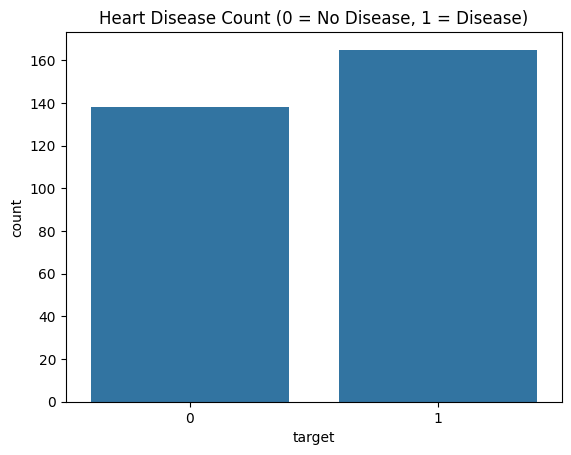

In [58]:
sns.countplot(x='target', data=data)
plt.title("Heart Disease Count (0 = No Disease, 1 = Disease)")
plt.show()

In [59]:
X = data.drop('target', axis=1)
y = data['target']

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (242, 13)
Testing data size: (61, 13)


In [61]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [62]:
def build_model(units1, units2, seed):
    # set seed so every model starts a bit different from others
    tf.random.set_seed(seed)

    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(units1, activation='relu'),
        layers.Dense(units2, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [63]:
models = []

In [64]:
model_settings = [
    {"units1": 16, "units2": 8, "seed": 1},
    {"units1": 32, "units2": 16, "seed": 2},
    {"units1": 8, "units2": 8, "seed": 3}
]

In [65]:
for i, setting in enumerate(model_settings):
    print("Training model", i + 1)

    model = build_model(setting["units1"], setting["units2"], setting["seed"])

Training model 1
Training model 2
Training model 3


In [66]:
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

In [67]:
 models.append(model)

print("All models trained successfully")

All models trained successfully


In [68]:
individual_accuracies = []

for i, model in enumerate(models):
    # get probability predictions and convert to 0 or 1
    pred_prob = model.predict(X_test, verbose=0)
    pred_label = (pred_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, pred_label)
    individual_accuracies.append(acc)
    print("Model", i + 1, "Accuracy:", acc)

Model 1 Accuracy: 0.8688524590163934


In [69]:
all_predictions = []

for model in models:
    pred_prob = model.predict(X_test, verbose=0)
    all_predictions.append(pred_prob)

In [70]:
all_predictions = np.array(all_predictions)

In [71]:
ensemble_prob = np.mean(all_predictions, axis=0)

In [72]:
ensemble_pred = (ensemble_prob > 0.5).astype(int).flatten()

In [73]:
ensemble_acc = accuracy_score(y_test, ensemble_pred)
print("Ensemble Model Accuracy:", ensemble_acc)

Ensemble Model Accuracy: 0.8688524590163934


In [74]:
results = {}
for i, acc in enumerate(individual_accuracies):
    results["Model " + str(i + 1)] = acc

results["Ensemble (Average)"] = ensemble_acc

In [75]:
for name, acc in results.items():
    print(name, ":", round(acc * 100, 2), "%")

Model 1 : 86.89 %
Ensemble (Average) : 86.89 %


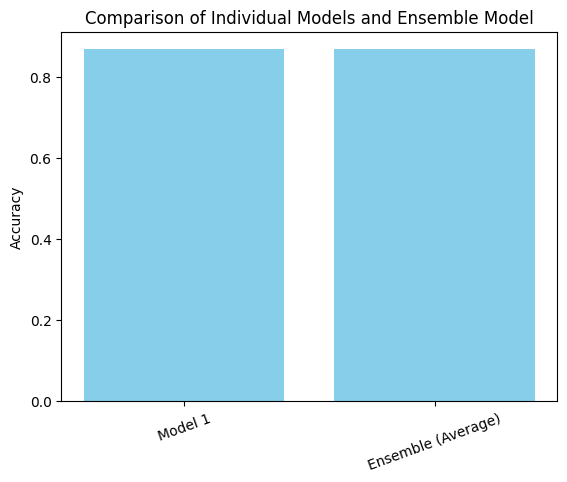

In [76]:
plt.bar(results.keys(), results.values(), color='skyblue')
plt.ylabel("Accuracy")
plt.title("Comparison of Individual Models and Ensemble Model")
plt.xticks(rotation=20)
plt.show()

In [77]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, ensemble_pred))

Confusion Matrix:
[[26  3]
 [ 5 27]]


In [78]:
print("Classification Report:")
print(classification_report(y_test, ensemble_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

